In [56]:
import kagglehub
import pandas as pd
import numpy as np
import polars as pl
import os
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

from kagglehub import KaggleDatasetAdapter

In [44]:

path = kagglehub.dataset_download(r"ranja7/vehicle-insurance-customer-data")
print(path)

C:\Users\YASH\.cache\kagglehub\datasets\ranja7\vehicle-insurance-customer-data\versions\1


In [46]:
os.listdir(path)
df = pd.read_csv(os.path.join(path,os.listdir(path)[0]))

In [47]:
def aggregate_column(col_name:str):

    return df.groupby(col_name).agg(count = ("Customer","count")).reset_index()

In [49]:
aggregate_column("Vehicle Size")

,Vehicle Size,count
0,Large,946
1,Medsize,6424
2,Small,1764


In [50]:
aggregate_column("Vehicle Class")

,Vehicle Class,count
0,Four-Door Car,4621
1,Luxury Car,163
2,Luxury SUV,184
3,SUV,1796
4,Sports Car,484
5,Two-Door Car,1886


In [51]:
df.isna().sum()

Customer                         0
State                            0
Customer Lifetime Value          0
Response                         0
Coverage                         0
Education                        0
Effective To Date                0
EmploymentStatus                 0
Gender                           0
Income                           0
Location Code                    0
Marital Status                   0
Monthly Premium Auto             0
Months Since Last Claim          0
Months Since Policy Inception    0
Number of Open Complaints        0
Number of Policies               0
Policy Type                      0
Policy                           0
Renew Offer Type                 0
Sales Channel                    0
Total Claim Amount               0
Vehicle Class                    0
Vehicle Size                     0
dtype: int64

In [53]:
px.violin(data_frame=df,
          x="Marital Status",
          y="Income")

In [54]:
df.head()

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,3/2/2011,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


In [55]:
df["Effective To Date"].min(),df["Effective To Date"].max()

('1/1/2011', '9/2/2011')

# Numerical Columns

In [37]:
df_num = df.select_dtypes(exclude=["object"])

In [38]:
df_num

,Customer Lifetime Value,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Total Claim Amount
0,2763.519279,56274,69,32,5,0,1,384.811147
1,6979.535903,0,94,13,42,0,8,1131.464935
2,12887.431650,48767,108,18,38,0,2,566.472247
3,7645.861827,0,106,18,65,0,7,529.881344
4,2813.692575,43836,73,12,44,0,1,138.130879
...,...,...,...,...,...,...,...,...
9129,23405.987980,71941,73,18,89,0,2,198.234764
9130,3096.511217,21604,79,14,28,0,1,379.200000
9131,8163.890428,0,85,9,37,3,2,790.784983
9132,7524.442436,21941,96,34,3,0,3,691.200000


<Axes: xlabel='Customer Lifetime Value', ylabel='Density'>

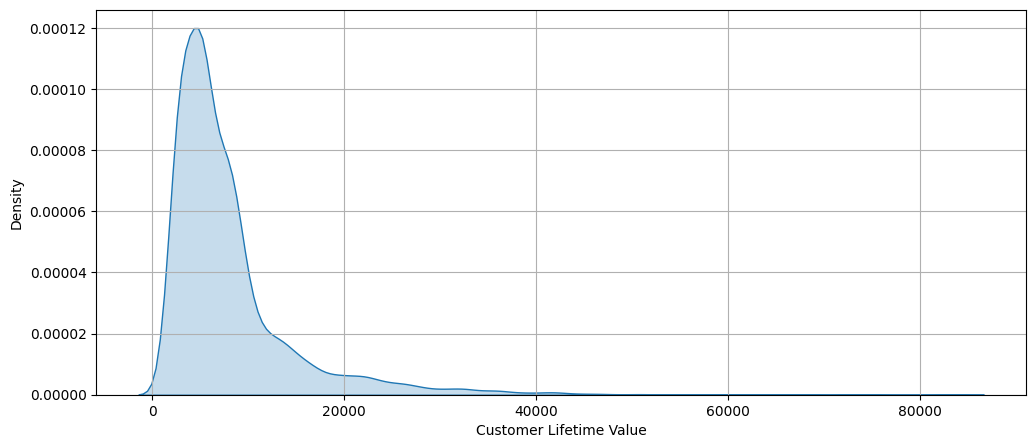

In [58]:
plt.figure(figsize=(12,5))
plt.grid(True)
sns.kdeplot(data=df_num,x="Customer Lifetime Value",fill=True)

<Axes: xlabel='Income', ylabel='Density'>

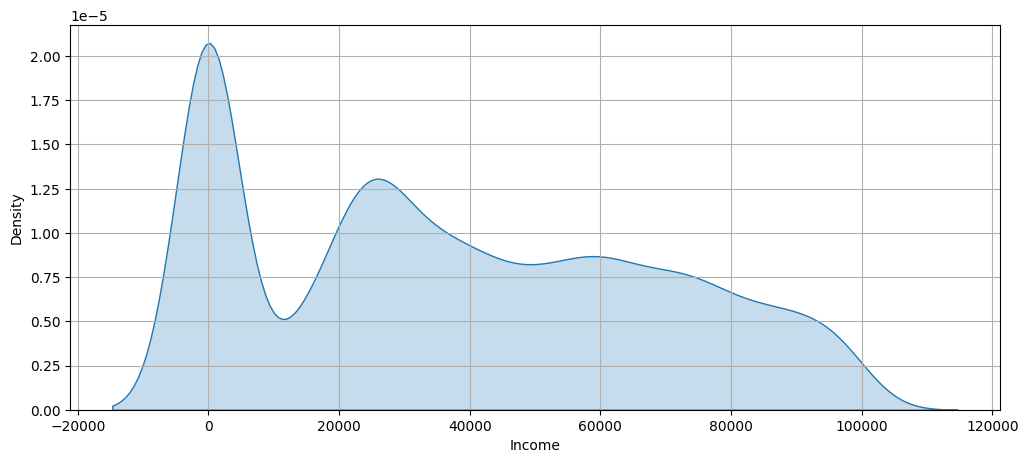

In [60]:
plt.figure(figsize=(12,5))
plt.grid(True)
sns.kdeplot(data=df_num,x="Income",fill=True)

In [61]:
df[df["Income"]==0]

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
7,CF85061,Arizona,7216.100311,No,Premium,Master,1/18/11,Unemployed,M,0,...,68,0,4,Corporate Auto,Corporate L3,Offer1,Agent,363.029680,Four-Door Car,Medsize
10,SX51350,California,4738.992022,No,Basic,College,2/21/11,Unemployed,M,0,...,5,0,3,Personal Auto,Personal L3,Offer1,Agent,482.400000,Four-Door Car,Small
11,VQ65197,California,8197.197078,No,Basic,College,6/1/2011,Unemployed,F,0,...,87,0,3,Personal Auto,Personal L3,Offer2,Agent,528.000000,SUV,Medsize
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9123,WZ45103,California,5678.050167,Yes,Extended,Bachelor,1/19/11,Unemployed,F,0,...,44,0,3,Personal Auto,Personal L2,Offer2,Agent,364.800000,Four-Door Car,Small
9125,RX91025,California,19872.262000,No,Premium,High School or Below,1/31/11,Unemployed,M,0,...,35,0,2,Personal Auto,Personal L3,Offer1,Agent,1950.725547,SUV,Small
9126,AC13887,California,4628.995325,No,Basic,Bachelor,9/1/2011,Unemployed,M,0,...,21,0,4,Corporate Auto,Corporate L1,Offer1,Branch,482.400000,Two-Door Car,Medsize
9131,TD14365,California,8163.890428,No,Extended,Bachelor,6/2/2011,Unemployed,M,0,...,37,3,2,Corporate Auto,Corporate L2,Offer1,Branch,790.784983,Four-Door Car,Medsize


In [62]:
df_num.columns

Index(['Customer Lifetime Value', 'Income', 'Monthly Premium Auto',
       'Months Since Last Claim', 'Months Since Policy Inception',
       'Number of Open Complaints', 'Number of Policies',
       'Total Claim Amount'],
      dtype='object')

In [65]:
df.to_parquet(r"C:\Users\YASH\Desktop\coding\ml\insurance_data\datasets\vehicle_insurance_dataset_kaggle.parquet",
              index=False,
              compression="gzip")